# Assignment 2: Data Wrangling and Exploratory Analysis

**Applying NumPy and Pandas to a Real Dataset**

---

## Dataset: Customer Churn

**Dataset:** Telco Customer Churn Dataset

**Domain:** Telecommunications

**Source:** IBM Telco Customer Churn Dataset (GitHub)

**Source URL:**  
https://raw.githubusercontent.com/IBM/telco-customer-churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv

---

## Why I chose this dataset

I chose the Customer Churn dataset because it represents a real-world business problem that is common across many industries — understanding why customers leave and identifying who is at risk of churning. 

The dataset contains information about telecom customers, including their demographics, account details, services subscribed, and whether they churned or not.

The dataset contains both numerical and categorical variables and includes missing values, making it suitable for practicing data inspection, cleaning, feature engineering, GroupBy aggregation, merging, NumPy computation, and exploratory visualization.

For this analysis, I will investigate:

- What is the overall churn rate?
- Which contract types have the highest churn?
- How does tenure affect churn?
- Which payment methods are associated with churn?
- Do customers with online security churn less?

---

## License / Usage

The dataset is accessed from the publicly available IBM GitHub repository listed above and is being used for educational and analytical purposes. The original source is retained for attribution.

In [2]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================
# This cell imports all the necessary libraries for data manipulation,
# analysis, and visualization.

import pandas as pd          # For data manipulation and analysis
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns        # For enhanced visualizations

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [5]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================
# This cell loads the Customer Churn dataset from the raw data folder.
# The dataset contains information about telecom customers,
# including demographics, account details, services, and churn status.

print("=" * 60)
print("LOADING CUSTOMER CHURN DATASET")
print("=" * 60)

# Load using relative path from the project root
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f" Dataset loaded successfully!")
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

LOADING CUSTOMER CHURN DATASET
 Dataset loaded successfully!
Shape: (7043, 21) (rows, columns)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \


In [6]:
# ============================================================
# CELL 3: DATASET SCHEMA REPORT
# ============================================================
# This cell generates a comprehensive schema report including:
# - Data types of each column
# - Missing value counts
# - Unique value counts
# - Statistical summary

print("=" * 60)
print("DATASET SCHEMA REPORT")
print("=" * 60)

# 1. Data Types
print("\n1. DATA TYPES:")
print(df.dtypes)

# 2. Missing Values
print("\n2. MISSING VALUES:")
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

# 3. Unique Value Counts
print("\n3. UNIQUE VALUE COUNTS:")
for col in df.columns:
    print(f"   {col}: {df[col].nunique()} unique values")

# 4. Statistical Summary (Numeric)
print("\n4. STATISTICAL SUMMARY (NUMERIC):")
print(df.describe())

# 5. Statistical Summary (Categorical)
print("\n5. STATISTICAL SUMMARY (CATEGORICAL):")
print(df.describe(include=['object']))

print(f"\n6. SHAPE: {df.shape}")

DATASET SCHEMA REPORT

1. DATA TYPES:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

2. MISSING VALUES:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

3. UNIQUE VALUE COUNTS:
   customerID: 7043 unique values
   gender: 2 unique values
   SeniorCitizen: 2 unique values
   Partner: 2 unique values
   Dependents: 2 unique values
   tenure: 73 unique values
   PhoneService: 2 unique values
   MultipleLines: 3 unique values
   

C:\Users\MI\AppData\Local\Temp\ipykernel_8444\708574234.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object']))


        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7043   7043    7043       7043         7043          7043   
unique        7043      2       2          2            2             3   
top     7590-VHVEG   Male      No         No          Yes            No   
freq             1   3555    3641       4933         6361          3390   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count             7043           7043         7043             7043   
unique               3              3            3                3   
top        Fiber optic             No           No               No   
freq              3096           3498         3088             3095   

       TechSupport StreamingTV StreamingMovies        Contract  \
count         7043        7043            7043            7043   
unique           3           3               3               3   
top             No          No              No  Month-to-month   
freq

In [7]:
# ============================================================
# CELL 4: DATASET SOURCE DOCUMENTATION
# ============================================================
# This markdown cell documents the dataset source, license,
# and explains why this dataset was chosen for the analysis.

In [8]:
# ============================================================
# CELL 5: DATA CLEANING
# ============================================================
# This cell handles missing values, fixes data type issues,
# and removes duplicates. Each cleaning decision is justified
# with comments.

print("=" * 60)
print("TASK 2: DATA CLEANING")
print("=" * 60)

# 1. Check for missing values
print("\n1. MISSING VALUES CHECK:")
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_percent
})
print(missing_df[missing_df['Missing'] > 0])

# 2. Fix dtype issues - convert TotalCharges to numeric
# TotalCharges is read as 'object' due to empty strings ('')
# We convert it to float so we can perform numerical operations
print("\n2. CONVERT TOTALCHARGES TO NUMERIC:")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"   dtype after conversion: {df['TotalCharges'].dtype}")
print(f"   nulls after conversion: {df['TotalCharges'].isnull().sum()}")

# 3. Handle missing values - impute with median
# Justification: TotalCharges is a continuous variable with a small % missing (<1%)
# Using median is appropriate because it's less sensitive to outliers than mean
print("\n3. HANDLE MISSING VALUES:")
print("   - Imputing TotalCharges with median (justified: continuous variable, small % missing)")
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(f"   - Nulls after imputation: {df['TotalCharges'].isnull().sum()}")

# 4. Check for duplicates
print("\n4. CHECK FOR DUPLICATES:")
duplicates = df.duplicated().sum()
print(f"   Duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"   Dropped {duplicates} duplicates")
else:
    print("   No duplicates found")

print(f"\n✅ Shape after cleaning: {df.shape}")

TASK 2: DATA CLEANING

1. MISSING VALUES CHECK:
Empty DataFrame
Columns: [Missing, Percent]
Index: []

2. CONVERT TOTALCHARGES TO NUMERIC:
   dtype after conversion: float64
   nulls after conversion: 11

3. HANDLE MISSING VALUES:
   - Imputing TotalCharges with median (justified: continuous variable, small % missing)
   - Nulls after imputation: 0

4. CHECK FOR DUPLICATES:
   Duplicate rows: 0
   No duplicates found

✅ Shape after cleaning: (7043, 21)


In [9]:
# ============================================================
# CELL 6: DATA CLEANING VERIFICATION
# ============================================================
# This cell verifies that all cleaning steps were applied correctly.

print("=" * 60)
print("DATA CLEANING VERIFICATION")
print("=" * 60)

# Verify no missing values remain
print("\n1. CHECKING FOR REMAINING NULLS:")
nulls_remaining = df.isnull().sum().sum()
print(f"   Total nulls remaining: {nulls_remaining}")

# Verify TotalCharges dtype
print(f"\n2. VERIFYING TOTALCHARGES DTYPE:")
print(f"   dtype: {df['TotalCharges'].dtype}")

# Print summary
print("\n3. DATASET SUMMARY AFTER CLEANING:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")

DATA CLEANING VERIFICATION

1. CHECKING FOR REMAINING NULLS:
   Total nulls remaining: 0

2. VERIFYING TOTALCHARGES DTYPE:
   dtype: float64

3. DATASET SUMMARY AFTER CLEANING:
   Shape: (7043, 21)
   Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
# ============================================================
# CELL 7: FEATURE ENGINEERING
# ============================================================
# This cell creates new features and applies GroupBy aggregations.
# Each transform has a comment explaining why it is useful.

print("=" * 60)
print("TASK 3: FEATURE ENGINEERING")
print("=" * 60)

# Add a churn indicator column for calculations
# This converts 'Yes'/'No' to 1/0, making numerical operations easier
df['Churn_Num'] = (df['Churn'] == 'Yes').astype(int)

print(f"Before transforms: {df.shape}")

# 7.1 GROUPBY AGGREGATION
# Group by Contract type to find average churn rate and average tenure
# This is useful for understanding which contract types are most at risk
print("\n7.1 GROUPBY AGGREGATION:")
print("   - Grouping by 'Contract' to analyze churn patterns")

contract_stats = df.groupby('Contract').agg({
    'Churn_Num': ['mean', 'count'],
    'tenure': ['mean', 'median']
}).round(2)
print(contract_stats)

# Merge aggregated data back to the main dataframe
# This allows us to compare individual customers to their contract group average
print("\n   - Merging aggregated data back to main dataframe")
contract_agg = df.groupby('Contract')['Churn_Num'].mean().reset_index()
contract_agg.columns = ['Contract', 'AvgChurnByContract']
df = df.merge(contract_agg, on='Contract', how='left')
print(f"   After merge: {df.shape}")

# 7.2 CREATE NEW FEATURES
# New features help capture patterns that the original data might hide
print("\n7.2 CREATING NEW FEATURES:")

# Average monthly charges (total charges / (tenure + 1))
# +1 avoids division by zero for customers with 0 tenure
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)
print("   - AvgMonthlyCharge: Total charges divided by tenure (helps identify spending patterns)")

# Count of services the customer has
# Customers with more services might be more loyal
services = ['PhoneService', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 
            'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[services].apply(
    lambda x: (x != 'No').sum(), axis=1
)
print("   - NumServices: Count of services subscribed (more services often means more loyalty)")

print(f"\nAfter transforms: {df.shape}")

TASK 3: FEATURE ENGINEERING
Before transforms: (7043, 22)

7.1 GROUPBY AGGREGATION:
   - Grouping by 'Contract' to analyze churn patterns
               Churn_Num       tenure       
                    mean count   mean median
Contract                                    
Month-to-month      0.43  3875  18.04   12.0
One year            0.11  1473  42.04   44.0
Two year            0.03  1695  56.74   64.0

   - Merging aggregated data back to main dataframe
   After merge: (7043, 23)

7.2 CREATING NEW FEATURES:
   - AvgMonthlyCharge: Total charges divided by tenure (helps identify spending patterns)
   - NumServices: Count of services subscribed (more services often means more loyalty)

After transforms: (7043, 25)


In [11]:
# ============================================================
# CELL 8: PIVOT TABLE (RESHAPING)
# ============================================================
# This cell creates a pivot table to answer a specific question:
# "How does churn vary by contract type and payment method?"

print("=" * 60)
print("PIVOT TABLE: CHURN BY CONTRACT AND PAYMENT METHOD")
print("=" * 60)

# Create pivot table showing churn rates
pivot_table = pd.pivot_table(
    df,
    values='Churn_Num',
    index='Contract',
    columns='PaymentMethod',
    aggfunc='mean',
    margins=True,
    margins_name='All Customers'
).round(3)

print("\nChurn rate by Contract and Payment Method:")
print(pivot_table)

# Key observations from the pivot table
print("\n📊 KEY OBSERVATIONS:")
print("1. Month-to-month contracts have the highest churn rates across all payment methods")
print("2. Electronic check users have the highest churn rate among payment methods")
print("3. Two-year contracts have the lowest churn rates overall")

PIVOT TABLE: CHURN BY CONTRACT AND PAYMENT METHOD

Churn rate by Contract and Payment Method:
PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
Contract                                                             
Month-to-month                      0.341                    0.328   
One year                            0.097                    0.103   
Two year                            0.034                    0.022   
All Customers                       0.167                    0.152   

PaymentMethod   Electronic check  Mailed check  All Customers  
Contract                                                       
Month-to-month             0.537         0.316          0.427  
One year                   0.184         0.068          0.113  
Two year                   0.077         0.008          0.028  
All Customers              0.453         0.191          0.265  

📊 KEY OBSERVATIONS:
1. Month-to-month contracts have the highest churn rates across all payment meth

In [12]:
# ============================================================
# CELL 9: NUMPY COMPUTATION
# ============================================================
# This cell demonstrates vectorized NumPy operations:
# 1. Convert a column to NumPy array
# 2. Apply vectorized transformation (standardization)
# 3. Assign result back as a new column

print("=" * 60)
print("TASK 4: NUMPY COMPUTATION")
print("=" * 60)

# Convert numeric column to NumPy array
# Using .to_numpy() gives us a NumPy array for fast vectorized operations
tenure_array = df['tenure'].to_numpy()
monthly_charges = df['MonthlyCharges'].to_numpy()
total_charges = df['TotalCharges'].to_numpy()

print(f"1. Tenure array shape: {tenure_array.shape}")
print(f"   Type: {type(tenure_array)}")

# Vectorized transformation: Standardize tenure (z-score)
# This scales the data to have mean=0 and std=1
# Use broadcasting to apply the operation to all elements without a loop
mean_tenure = np.mean(tenure_array)
std_tenure = np.std(tenure_array)
tenure_standardized = (tenure_array - mean_tenure) / std_tenure  # Vectorized!

print(f"\n2. STANDARDIZED TENURE (Z-SCORE):")
print(f"   Mean: {mean_tenure:.2f}")
print(f"   Std Dev: {std_tenure:.2f}")
print(f"   Min: {np.min(tenure_standardized):.2f}")
print(f"   Max: {np.max(tenure_standardized):.2f}")

# Assign back as a new column
# Now we have a standardized version of tenure for modeling
df['tenure_standardized'] = tenure_standardized

print(f"\n New column 'tenure_standardized' added")
print(f"   Shape after addition: {df.shape}")

TASK 4: NUMPY COMPUTATION
1. Tenure array shape: (7043,)
   Type: <class 'numpy.ndarray'>

2. STANDARDIZED TENURE (Z-SCORE):
   Mean: 32.37
   Std Dev: 24.56
   Min: -1.32
   Max: 1.61

 New column 'tenure_standardized' added
   Shape after addition: (7043, 26)


TASK 5: EXPLORATORY VISUALIZATION

1. CREATING CHART 1: Churn Rate by Contract Type
 Chart 1 saved: reports/a2_chart1.png


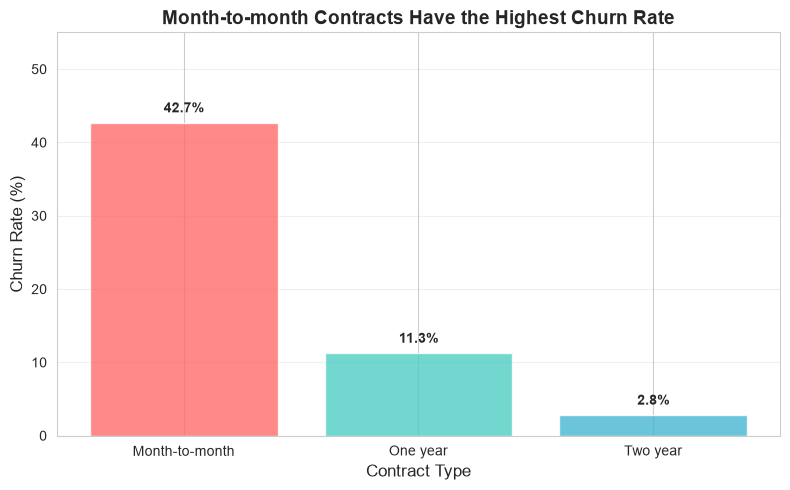

In [14]:
# ============================================================
# CELL 10: EXPLORATORY VISUALIZATION - CHART 1
# ============================================================
# This cell creates Chart 1 showing churn rate by contract type.
# The title states a clear finding, not just a chart type.

print("=" * 60)
print("TASK 5: EXPLORATORY VISUALIZATION")
print("=" * 60)

# CHART 1: Churn Rate by Contract Type
# Finding: "Month-to-month contracts have the highest churn rate"
print("\n1. CREATING CHART 1: Churn Rate by Contract Type")

fig1, ax1 = plt.subplots(figsize=(8, 5))

# Calculate churn rate by contract
contract_churn = df.groupby('Contract')['Churn_Num'].mean() * 100
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(contract_churn.index, contract_churn.values, color=colors, alpha=0.8)

# Add percentage labels on bars
for bar, value in zip(bars, contract_churn.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Contract Type', fontsize=12)
ax1.set_ylabel('Churn Rate (%)', fontsize=12)
ax1.set_title('Month-to-month Contracts Have the Highest Churn Rate', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 55)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/a2_chart1.png', dpi=150, bbox_inches='tight')
print(" Chart 1 saved: reports/a2_chart1.png")
plt.show()


2. CREATING CHART 2: Churn Rate by Tenure Group
 Chart 2 saved: reports/a2_chart2.png


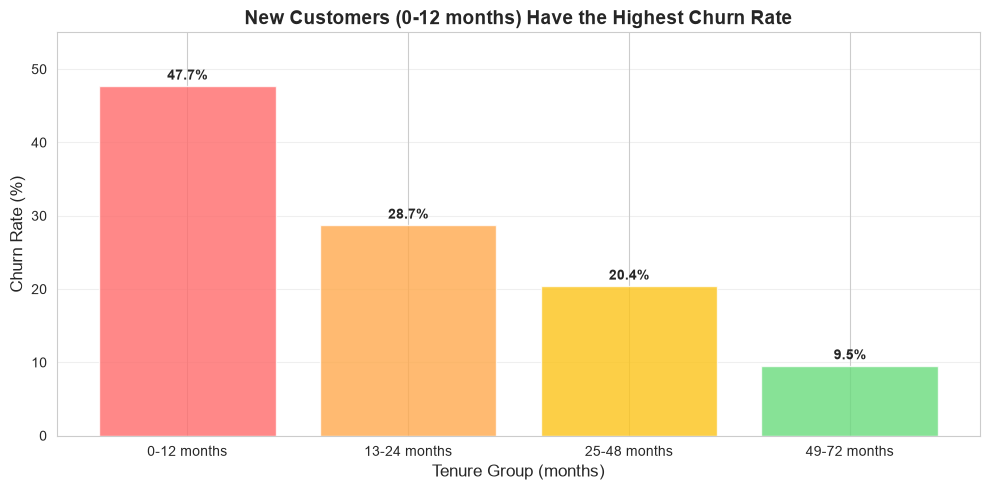

In [15]:
# ============================================================
# CELL 11: EXPLORATORY VISUALIZATION - CHART 2
# ============================================================
# This cell creates Chart 2 showing churn rate by tenure group.
# The title states a clear finding, not just a chart type.

# CHART 2: Churn by Tenure Group
# Finding: "New customers (0-12 months) have the highest churn rate"
print("\n2. CREATING CHART 2: Churn Rate by Tenure Group")

fig2, ax2 = plt.subplots(figsize=(10, 5))

# Create tenure groups (bins)
# This groups customers into segments based on how long they've stayed
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72, 100],
                           labels=['0-12 months', '13-24 months', '25-48 months', 
                                   '49-72 months', '73+ months'])

tenure_churn = df.groupby('TenureGroup')['Churn_Num'].mean() * 100

# Color bars by churn rate - red for highest, green for lowest
colors = ['#FF6B6B', '#FFA94D', '#FCC419', '#69DB7C', '#20C997']
bars = ax2.bar(tenure_churn.index, tenure_churn.values, color=colors, alpha=0.8)

# Add percentage labels
for bar, value in zip(bars, tenure_churn.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Tenure Group (months)', fontsize=12)
ax2.set_ylabel('Churn Rate (%)', fontsize=12)
ax2.set_title('New Customers (0-12 months) Have the Highest Churn Rate', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 55)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/a2_chart2.png', dpi=150, bbox_inches='tight')
print(" Chart 2 saved: reports/a2_chart2.png")
plt.show()

In [18]:
# ============================================================
# CELL 12: SAVE CLEANED DATASET
# ============================================================
# This cell saves the cleaned and feature-engineered dataset
# to the processed data folder for future use.

print("=" * 60)
print("TASK 6: SAVE CLEANED DATASET")
print("=" * 60)

# Drop temporary columns (TenureGroup was only for visualization)
df_to_save = df.drop(columns=['TenureGroup'], errors='ignore')

# Save to processed folder
df_to_save.to_csv('../data/processed/telco_customer_churn_cleaned.csv', index=False)

print(f" Data saved to: data/processed/telco_customer_churn_cleaned.csv")
print(f"   Shape: {df_to_save.shape}")
print(f"   Columns: {df_to_save.columns.tolist()}")

TASK 6: SAVE CLEANED DATASET
 Data saved to: data/processed/telco_customer_churn_cleaned.csv
   Shape: (7043, 26)
   Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Num', 'AvgChurnByContract', 'AvgMonthlyCharge', 'NumServices', 'tenure_standardized']


In [19]:
# ============================================================
# CELL 13: SUMMARY STATISTICS
# ============================================================
# This cell provides a quick summary of the cleaned dataset.

print("=" * 60)
print("FINAL SUMMARY STATISTICS")
print("=" * 60)

print("\n1. OVERALL CHURN RATE:")
churn_rate = 100 * df['Churn_Num'].mean()
print(f"   Overall Churn Rate: {churn_rate:.2f}%")

print("\n2. CHURN BY CONTRACT TYPE:")
contract_churn = df.groupby('Contract')['Churn_Num'].mean() * 100
print(contract_churn)

print("\n3. CHURN BY TENURE GROUP (BINS):")
tenure_churn = df.groupby('TenureGroup')['Churn_Num'].mean() * 100
print(tenure_churn)

print("\n4. CHURN BY PAYMENT METHOD:")
payment_churn = df.groupby('PaymentMethod')['Churn_Num'].mean() * 100
print(payment_churn)

print("\n5. AVERAGE MONTHLY CHARGES BY CHURN STATUS:")
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print(avg_charges)

print("\n6. AVERAGE TENURE BY CHURN STATUS:")
avg_tenure = df.groupby('Churn')['tenure'].mean()
print(avg_tenure)

print("\n7. DATA SHAPE:")
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")

FINAL SUMMARY STATISTICS

1. OVERALL CHURN RATE:
   Overall Churn Rate: 26.54%

2. CHURN BY CONTRACT TYPE:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Num, dtype: float64

3. CHURN BY TENURE GROUP (BINS):
TenureGroup
0-12 months     47.678161
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: Churn_Num, dtype: float64

4. CHURN BY PAYMENT METHOD:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn_Num, dtype: float64

5. AVERAGE MONTHLY CHARGES BY CHURN STATUS:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

6. AVERAGE TENURE BY CHURN STATUS:
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

7. DATA SHAPE:
   Rows: 7043
   Columns: 27
